<a href="https://colab.research.google.com/github/NaydelinAidee/Procesos-Estocasticos/blob/main/CaminataAleatoria_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminatas Aleatorias

Las caminatas aleatorias son modelos matemáticos y estocásticos que describen una trayectoria consistente en una serie de pasos sucesivos tomados al azar, comúnmente en una cuadrícula, red o recta numérica. Cada movimiento es independiente y su dirección/longitud se determina probabilísticamente, representando la posición de un objeto que se aleja de su punto de inicio.
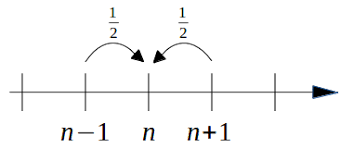

Veamos ahora un ejemplo de una caminata alatoria 1D, con probabilidad p de moverse a la derecha y probabilidad q de moverse a la izquierda, tal que p + q = 1.

Primero tenemos que mandar a llamar a las librerias que vamos a ocupar, random se usara para generar nuestros numeros aleatorios, despues usamos matplotlib para frafucar nuestra función.

In [9]:
import random
import matplotlib.pyplot as plt

Definimos la función de la caminata aleatoria, aqui vamos a poner el valor de p=0.5, decimos en que posición se inicia, y lógicamente como vimos en la imagen se inicia en 0, por ende se define posición=0.


Ahora en la variable historial se hace una lista que registra la posición en cada unidad de tiempo $(t)$.
Por ejemplo en el paso 1=[0], en el paso 2=[0,1] que pues va a inducar que se movió una unidad a la derecha y asi sucesivamente.

Ahora para el ciclo for le decumos que nuestra función a trozos debe repetirse n_pasos y estando dentro se ejecuta la función , primeramente generamos un número aleatorio , despues de esto en nuestra funcion a trozos ponemos un condicional para ver si avanza a la derecha (1) o a la izquierrda(-1).


Posteriormente  se hace un contador de como van moviendose nuestros pasos o bien la caminata, todo esto se va guardando en la variable historial.


In [10]:
def camino_aleatorio_simetrico(n_pasos):
    p = 0.5
    posicion = 0# partimos de 0 asi como en la recta
    historial = [posicion]#va guardandk en que posicion vamos

    for _ in range(n_pasos):
        r = random.random()

        # Función para ver si me voy a la derecha o a la izquierda
        if r < p:
            paso = 1  # Derecha
        else:
            paso = -1 # Izquierda

        posicion += paso#contador de pasos
        historial.append(posicion)#guardo mi informacion

    return historial

Ahora vamos a elegir el número de pasos que  queremos para nuestra simulación.

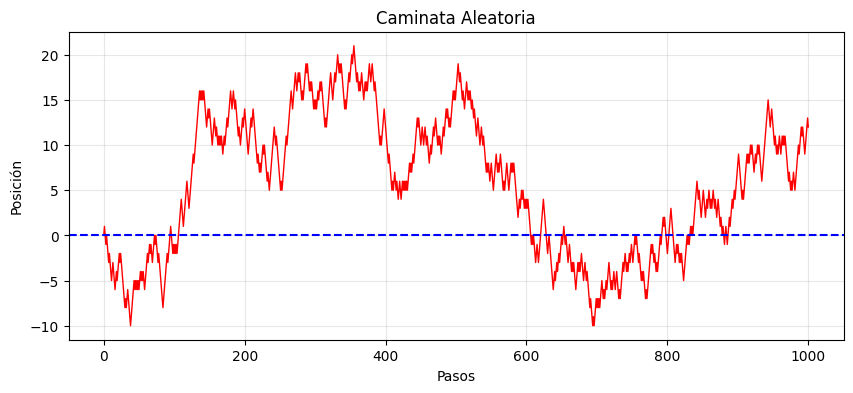

In [11]:
# Ahora piedogacer la simulacion  con 1000 pasos
pasos = 1000
datos = camino_aleatorio_simetrico(pasos)

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(datos, color='red', linewidth=1)
plt.axhline(0, color='blue', linestyle='--') # Eje central
plt.title("Caminata Aleatoria")
plt.xlabel("Pasos")
plt.ylabel("Posición")
plt.grid(alpha=0.3)
plt.show()

Ahora podemos cuestionarnos un poco acerca de esta caminata, por ejemplo:



*   ¿Dónde terminará la partícula si p=0.5?


Se crea una lista vacía llamada finales. Su único objetivo es guardar el número de la casilla donde terminó cada una de las 1,000 caminatas.


El for es para realizar la simulacion 1000 veces.

El índice [-1] significa "el último elemento de la lista" ya que no  me interesa saber qué pasó en el paso 5 o 50, solo quiero saber en qué posición quedó la partícula al final del paso 200.

Despues se calcula el promedio.



In [14]:

finales = []
for i in range(1000):
    recorrido = camino_aleatorio_simetrico(200) # Hacemos 200 pasos
    posicion_final = recorrido[-1]             # Tomamos el último dato
    finales.append(posicion_final)

promedio = sum(finales) / len(finales)
print(f"El promedio de los finales de 1000 caminatas es: {promedio}")

El promedio de los finales de 1000 caminatas es: 0.148


Ahora veamos ¿A qué distancia del origen suele estar la partícula?



In [15]:
distancias_absolutas = []

for i in range(1000):
    recorrido = camino_aleatorio_simetrico(400) # n = 400
    posicion_final = recorrido[-1]

    # Usamos abs() para convertir negativos en positivos
    # Queremos saber "qué tan lejos", no "hacia qué lado"
    distancias_absolutas.append(abs(posicion_final))

promedio_distancia = sum(distancias_absolutas) / len(distancias_absolutas)

print(f"Distancia promedio después de 400 pasos: {promedio_distancia}")
print(f"Raíz cuadrada de 400 es: {400**0.5}")

Distancia promedio después de 400 pasos: 15.846
Raíz cuadrada de 400 es: 20.0


Aunque el promedio de las posiciones es 0, la partícula se aleja del origen siguiendo una relación no lineal. La distancia promedio al centro no crece igual que el tiempo, sino de forma mucho más lenta: con la raíz cuadrada de los pasos.